In [ ]:
import numpy as np
import xarray as xr
import zarr
import dask
import dask.array as da
import time
import matplotlib.pyplot as plt
import pystac_client
import stackstac
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numcodecs
import json

In [ ]:
# query the Sentinel 2 L2A collection and store results

stac_url = 'https://earth-search.aws.element84.com/v1'
collection = 'sentinel-2-l2a'

# Small AOI over Vienna
bbox = [16.20, 48.10, 16.50, 48.30]  # [west, south, east, north]
date_range = '2023-06-01/2023-09-30'        # summer — low cloud cover
max_cloud_cover = 20

catalog = pystac_client.Client.open(stac_url)

search = catalog.search(
    collections=collection,
    bbox=bbox,
    datetime=date_range,
    query=[f'eo:cloud_cover<{max_cloud_cover}']
)

items = list(search.items())
print(f'Found {len(items)} scenes')

Found 36 scenes


In [ ]:
# combine all 36 items into one dask array chunked along time and band

ndvi_bands = ['red', 'nir'] # grab only the two bands from the items
resolution = 60 # meters, for stackstac. it will resample everything to match this resolution
epsg = items[0].properties['proj:code'].split(':')[-1] # grab the code component from proj:code

# stack all 36 scenes' assets into one dask array
stack = stackstac.stack(
    items,
    assets=ndvi_bands,
    resolution=resolution,
    bounds_latlon=bbox,
    epsg=int(epsg)
)

t_shape, b_shape, y_shape, x_shape = stack.shape
stack = stack.dropna(dim='time', how='all') # drop any item that contains all null time values (edge tiles)
stack

<xarray.DataArray 'stackstac-efc2df6fcfb87e30f59305f6ad0d51f6' (time: 36,
                                                                band: 2,
                                                                y: 378, x: 379)> Size: 83MB
dask.array<getitem, shape=(36, 2, 378, 379), dtype=float64, chunksize=(1, 1, 378, 379), chunktype=numpy.ndarray>
Coordinates: (12/52)
  * time                                     (time) datetime64[us] 288B 2023-...
    id                                       (time) <U24 3kB 'S2B_33UXP_20230...
    s2:degraded_msi_data_percentage          (time) float64 288B 0.0221 ... 0...
    created                                  (time) <U24 3kB '2023-06-01T20:1...
    s2:processing_baseline                   (time) <U5 720B '05.09' ... '05.09'
    earthsearch:s3_path                      (time) <U79 11kB 's3://sentinel-...
    ...                                       ...
    mgrs:utm_zone                            int64 8B 33
    proj:code                                <U10 40B 'EPSG:32633'
    earthsearch:boa_offset_applied           bool 1B True
    gsd                                      int64 8B 10
    proj:shape                               object 8B {10980}
    epsg                                     int64 8B 32633
Attributes:
    spec:        RasterSpec(epsg=32633, bounds=(588960, 5328060, 611700, 5350...
    crs:         epsg:32633
    transform:   | 60.00, 0.00, 588960.00|\n| 0.00,-60.00, 5350740.00|\n| 0.0...
    resolution:  60

In [ ]:
# define NDVI formula and the three different chunking strategies

def ndvi(ds):
    return (ds['nir'] - ds['red']) / (ds['nir'] + ds['red'])

spatial = { # great for spatial analyses where time doesn't matter (NDVI maps for each date)
    'time': 1,
    'band': 1,
    'y': y_shape,
    'x': x_shape
    }

temporal = { # great for temporal analyses where spatial doesn't matter (per-pixel ndvi over time)
    'time': t_shape,
    'band': 1,
    'y': 64,
    'x': 64
}

balanced = { # mix of both, used if both temporal and spatial analyses are expected
    'time': 4,
    'band': 1,
    'y': 256,
    'x': 256
}

chunk_strats = {
    'spatial': spatial,
    'temporal': temporal,
    'balanced': balanced
}

In [6]:
# spin up a local dask cluster
# Open http://localhost:8787 in a browser to watch the task graph live.
cluster = LocalCluster(n_workers=4, threads_per_worker=2)
client  = Client(cluster)
print(client)
print(f'Dashboard: {client.dashboard_link}')

<Client: 'tcp://127.0.0.1:34673' processes=4 threads=8, memory=15.26 GiB>
Dashboard: http://127.0.0.1:8787/status


2026-06-13 23:49:30,863 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ff9cb1c309917e073e0a52c1f7c6af8f initialized by task ('rechunk-merge-rechunk-transfer-0a0d2f327059284bc62da826a9419606', 0, 0, 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:35819
2026-06-13 23:49:33,922 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ff9cb1c309917e073e0a52c1f7c6af8f deactivated due to stimulus 'task-finished-1781419773.9200459'
2026-06-13 23:49:37,374 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 7182fba35a20eaefc481b3ba06d47b00 initialized by task ('rechunk-merge-rechunk-transfer-0a0d2f327059284bc62da826a9419606', 0, 1, 0, 0, 0, 1, 0, 0) executed on worker tcp://127.0.0.1:41805
2026-06-13 23:49:37,840 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 7182fba35a20eaefc481b3ba06d47b00 deactivated due to stimulus 'task-finished-1781419777.8379471'


In [ ]:
# convert dask array to zarr by each chunking strategy, recording write times for each.
compressor = numcodecs.Blosc(cname='lz4', clevel=5, shuffle=numcodecs.Blosc.BITSHUFFLE)
output_dir = Path('./zarr_stores_2')
output_dir.mkdir(exist_ok=True)

write_times = {}

def clean_zarr(d):
    # delete coordinates that are Python objects and cannot cast to a Zarr dtype
    bad_coords = [name for name, coord in d.coords.items() if coord.dtype == object]
    if bad_coords:
        print(f'dropping Python object coordinates: {bad_coords}')
    d = d.drop_vars(bad_coords)

    # keep only JSON-serializable attributes, since only those are valid Zarr attributes
    clean_attrs = {}
    for name, attr in d.attrs.items():
        try: # if attribute can be successfull JSON serialized, store the attribute data and its name in the clean_attrs dict
            json.dumps(attr)
            clean_attrs[name] = attr
        except (TypeError, ValueError): # if the attribute cannot be JSON serialized, skip
            pass
    d.attrs = clean_attrs # assign the clean_attrs dict as attributes to the dataset
    return d

for strat, chunks in chunk_strats.items():
    path = str(output_dir / f'sentinel2_{strat}.zarr')
    print(f"Writing '{strat}' -> {path}")
    t0 = time.time()

    ds = stack.chunk(chunks).to_dataset(dim='band')
    ds = clean_zarr(ds)

    ds.to_zarr(
        path,
        mode='w',
        zarr_format=2,
        encoding={v: {'compressor': compressor} for v in ndvi_bands},
        consolidated=True
    )

    elapsed = time.time() - t0
    write_times[strat] = elapsed

    print(f'{strat} done in {elapsed:.1f}s')

Writing 'spatial' -> zarr_stores_2/sentinel2_spatial.zarr
dropping Python object coordinates: ['s2:dark_features_percentage', 's2:snow_ice_percentage', 's2:nodata_pixel_percentage', 's2:granule_id', 's2:cloud_shadow_percentage', 'processing:software', 'proj:centroid', 'view:azimuth', 's2:tile_id', 'view:incidence_angle', 'proj:shape']
spatial done in 26.0s
Writing 'temporal' -> zarr_stores_2/sentinel2_temporal.zarr
dropping Python object coordinates: ['s2:dark_features_percentage', 's2:snow_ice_percentage', 's2:nodata_pixel_percentage', 's2:granule_id', 's2:cloud_shadow_percentage', 'processing:software', 'proj:centroid', 'view:azimuth', 's2:tile_id', 'view:incidence_angle', 'proj:shape']
temporal done in 19.3s
Writing 'balanced' -> zarr_stores_2/sentinel2_balanced.zarr
dropping Python object coordinates: ['s2:dark_features_percentage', 's2:snow_ice_percentage', 's2:nodata_pixel_percentage', 's2:granule_id', 's2:cloud_shadow_percentage', 'processing:software', 'proj:centroid', 'view:az

In [ ]:
# calculate ndvi time series and map for each zarr, recording compute time for each.
# goal: understand which chunking strategies work for which analyses

date_indx = 0 # grab the first time step
x_indx, y_indx = x_shape // 2, y_shape // 2 # center pixel

results = {}
print(f"{'Strategy':>10}  {'Spatial map':>12}  {'Time series':>12}")
print('-' * 42)

for strat in chunk_strats:
    path = str(output_dir / f'sentinel2_{strat}.zarr')
    ds = xr.open_zarr(path, consolidated=True)
    ndvi_calc = ndvi(ds)

    # spatial analysis
    t0 = time.time()
    ndvi_map = ndvi_calc.isel(time=date_indx).compute()
    t_spatial = time.time() - t0

    # temporal analysis
    t0 = time.time()
    ndvi_temporal = ndvi_calc.isel(y=y_indx, x=x_indx).compute()
    t_temporal = time.time() - t0

    results[strat] = {
        'spatial_s':  t_spatial,
        'temporal_s': t_temporal,
        'ndvi_map':   ndvi_map,
        'ndvi_ts':    ndvi_temporal,
    }

    print(f'{strat:>10}  {t_spatial:>10.2f}s  {t_temporal:>10.2f}s')

  Strategy   Spatial map   Time series
------------------------------------------
{'time': 1, 'band': 1, 'y': 378, 'x': 379}
   spatial        0.24s        2.30s
{'time': 36, 'band': 1, 'y': 64, 'x': 64}
  temporal        0.68s        0.40s
{'time': 4, 'band': 1, 'y': 256, 'x': 256}
  balanced        0.46s        1.21s


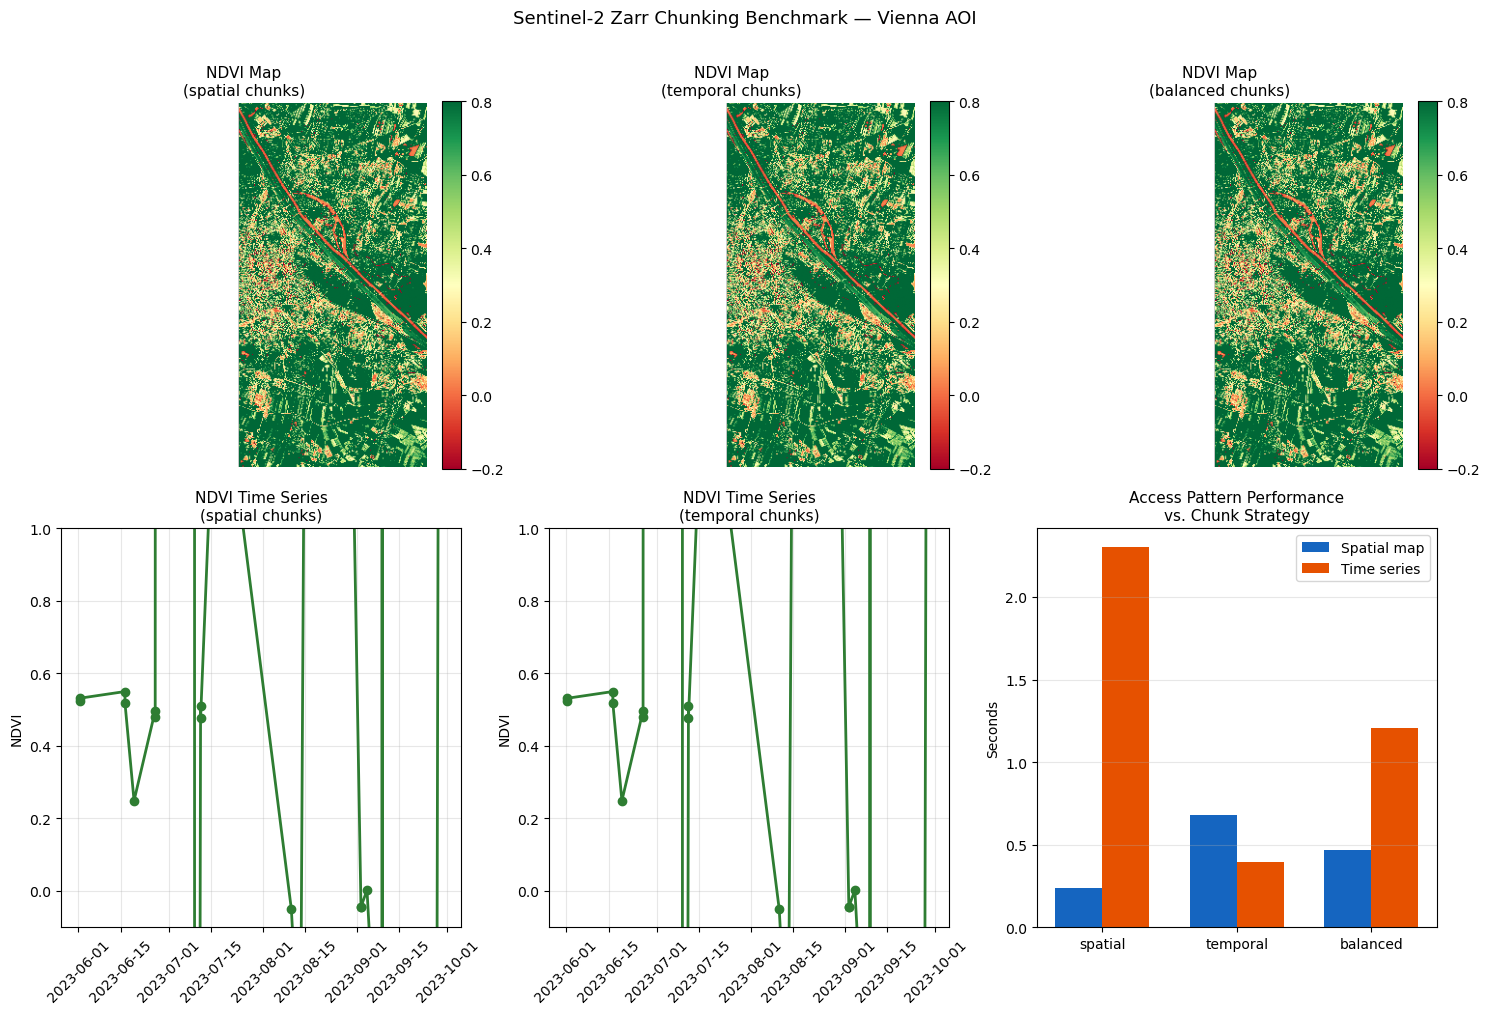

Saved: chunking_benchmark.png


In [ ]:
# plot the maps, time series, and bar chart showing time compute times for each of the chunking strategies.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
names = list(chunk_strats.keys())

# Row 1: NDVI maps
for i, name in enumerate(names):
    ax = axes[0, i]
    im = ax.imshow(results[name]['ndvi_map'].values, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
    ax.set_title(f'NDVI Map\n({name} chunks)', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Row 2: time series for two strategies
for i, name in enumerate(['spatial', 'temporal']):
    ax = axes[1, i]
    ts = results[name]['ndvi_ts']
    ax.plot(ts.time.values, ts.values, marker='o', linewidth=2, color='#2e7d32')
    ax.set_title(f'NDVI Time Series\n({name} chunks)', fontsize=11)
    ax.set_ylabel('NDVI')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(-0.1, 1.0)
    ax.grid(True, alpha=0.3)

# Benchmark bar chart
ax   = axes[1, 2]
x    = np.arange(len(names))
w    = 0.35
sp_t = [results[n]['spatial_s']  for n in names]
te_t = [results[n]['temporal_s'] for n in names]
ax.bar(x - w/2, sp_t, w, label='Spatial map',  color='#1565C0')
ax.bar(x + w/2, te_t, w, label='Time series', color='#E65100')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Seconds')
ax.set_title('Access Pattern Performance\nvs. Chunk Strategy', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Sentinel-2 Zarr Chunking Benchmark — Vienna AOI', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('chunking_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chunking_benchmark.png')
